In [1]:
import pandas as pd

from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [2]:
from helper import process_reference_composite

# math & safety

In [3]:
results_math = process_reference_composite(resmat, theta_df, a_df, b_series, ['math', 'gsm'])

Mean unit vector:  [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
Mean unit vector:  [-0.21494706 -0.22744916 -0.23566988 -0.1679211  -0.3850087  -0.2394518
  0.04993943  0.25944665 -0.39451882 -0.04396391 -0.01316161 -0.33871678
  0.30975133  0.06780565  0.26811373 -0.26613766  0.13065511 -0.04555357
 -0.08982014]
Used pre-computed direction vector. [-0.22217683 -0.23732743 -0.24023862 -0.1697346  -0.37846613 -0.24225266
  0.06519122  0.26698127 -0.39838114 -0.05022392 -0.01661013 -0.32513592
  0.30071217  0.06421725  0.2603656  -0.2678348   0.1399193  -0.03747842
 -0.08976768]
Used pre-computed direction vector. [-0.2121759  -0.22592627 -0.2385837  -0.16556206 -0.3867546  -0.24016796
  0.05153811  0.26446506 -0.3984767  -0.04828941 -0.01366189 -0.3356655
  0.30475757  0.05998956  0.26903284 -0.26501375

In [4]:
results_safety = process_reference_composite(resmat, theta_df, a_df, b_series, ['air_bench_2024'])

Mean unit vector:  [ 0.15788884  0.12192029 -0.20424938  0.14769147 -0.08909655  0.00674207
  0.13001913  0.38275072 -0.3342275  -0.27393126  0.03548491  0.25131562
 -0.28736213 -0.4951297   0.04810696  0.04254235  0.16937524  0.20083156
  0.27064428]
Mean unit vector:  [ 8.7650202e-02 -1.9348134e-01 -4.5048916e-03  3.0354402e-04
 -2.7384856e-01 -3.9389920e-01 -1.2806861e-01 -2.2029307e-01
  3.0856737e-01 -8.8170439e-02 -4.1135219e-01 -3.9413470e-01
 -1.6451129e-01 -1.1405341e-01  1.5675986e-01  1.0914784e-01
 -1.5494092e-02  3.2985809e-01  2.1595275e-01]
Used pre-computed direction vector. [ 8.3472341e-02 -1.9222133e-01 -2.7564226e-02  2.9497756e-02
 -2.8652298e-01 -3.8351992e-01 -1.0490729e-01 -2.0395660e-01
  2.7948627e-01 -7.9143204e-02 -4.0780070e-01 -3.9288455e-01
 -1.7605518e-01 -1.2034319e-01  1.8554886e-01  1.3114275e-01
  3.3247721e-04  3.5156754e-01  2.1662463e-01]
Used pre-computed direction vector. [ 0.09446862 -0.18845399 -0.01322626  0.00660722 -0.2779005  -0.39397007
 -

In [5]:
scores_math_pure = results_math['scores']
scores_safety_pure = results_safety['scores']

print('scores correlation', scores_math_pure.corr(scores_safety_pure))

mean_math_pure = scores_math_pure.mean()
mean_safety_pure = scores_safety_pure.mean()

v1 = results_math['v']
v2 = results_safety['v']

scores correlation 0.12400664066837515


In [6]:
scores_math_pure.sort_values(ascending=False)

meta/llama-3.1-405b-instruct-turbo          3.766188
deepseek-ai/deepseek-v3                     3.727743
meta/llama-3.2-90b-vision-instruct-turbo    3.581185
openai/gpt-4o-2024-08-06                    3.438040
qwen/qwen2.5-72b-instruct-turbo             3.326490
                                              ...   
AlephAlpha/luminous-extended               -2.654060
meta/llama-2-7b                            -2.755488
tiiuae/falcon-7b                           -2.848788
ai21/j1-grande-v2-beta                     -2.901797
ai21/j1-grande                             -3.007414
Name: ability, Length: 183, dtype: float32

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_88471/1530246873.py:310: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


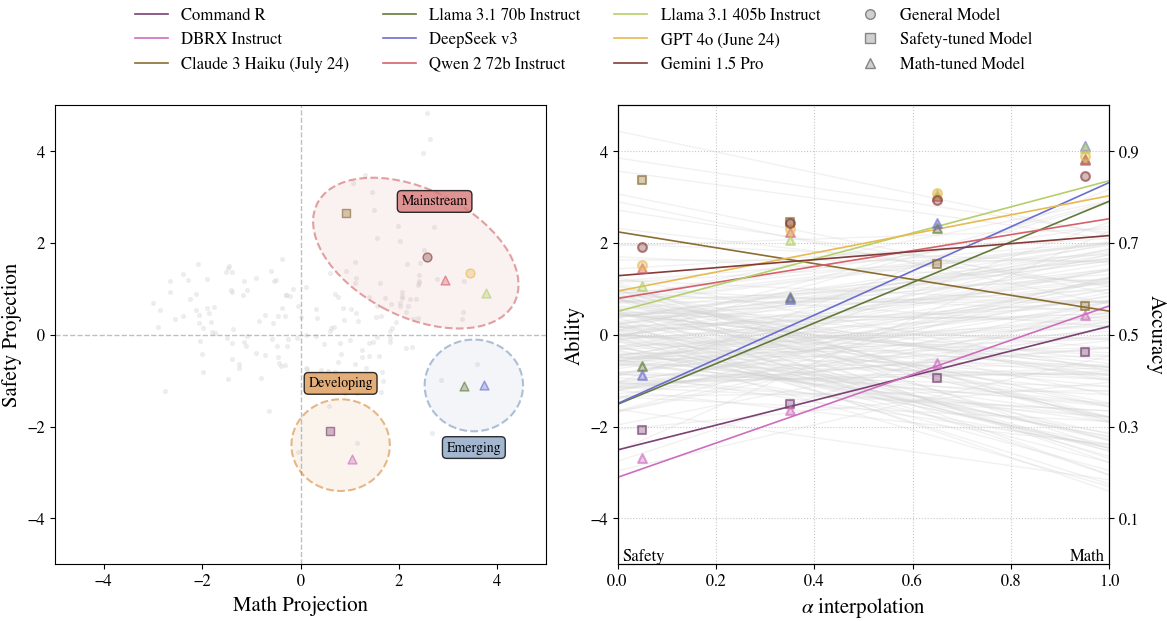

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D
import os, sys
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)


# Create combined figure with two subplots
# ax1 will now be the LEFT plot, ax2 will be the RIGHT plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Model classification and colors (shared between both plots)
model_classification = {
    'deepseek-ai/deepseek-v3': 'math',
    'meta/llama-3.1-70b-instruct-turbo': 'math',
    'meta/llama-3.1-405b-instruct-turbo': 'math',
    'anthropic/claude-3-haiku-20240307': 'safety',
    'openai/gpt-4o-2024-08-06': 'general',
    'google/gemini-1.5-pro-002': 'general',
    'qwen/qwen2-72b-instruct': 'math',
    'cohere/command-r': 'safety',
    'databricks/dbrx-instruct': 'math'
}

models_to_name = {
    'deepseek-ai/deepseek-v3': 'DeepSeek v3',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70b Instruct',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405b Instruct',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku (July 24)',
    'openai/gpt-4o-2024-08-06': 'GPT 4o (June 24)',
    'google/gemini-1.5-pro-002': 'Gemini 1.5 Pro',
    'qwen/qwen2-72b-instruct': 'Qwen 2 72b Instruct',
    'cohere/command-r': 'Command R',
    'databricks/dbrx-instruct': 'DBRX Instruct'
}

models_to_highlight = model_classification.keys()

# Define colors and markers for highlighted models (shared)
highlight_cmap = plt.get_cmap('tab20b')
# Clip the colormap to avoid overly bright/dark colors at the ends
from matplotlib.colors import LinearSegmentedColormap
def clipped_cmap(cmap, minval=0.08, maxval=0.92, n=256):
    return LinearSegmentedColormap.from_list(
        f'clipped({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )
highlight_cmap = clipped_cmap(highlight_cmap, minval=0.1)
num_highlight = len(models_to_highlight)
highlight_colors = [highlight_cmap(i / max(num_highlight - 1, 1)) for i in range(num_highlight)]
highlight_color_map = dict(zip(models_to_highlight, highlight_colors))


# ===== LEFT SUBPLOT: SCATTER PLOT (Formerly RIGHT) =====
# Get all models
mmlu_mean_full = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm', 'med_qa'])]].mean(axis=1)
all_indices = mmlu_mean_full.index

# Get PC1 and PC2 scores for all models
all_pc1 = scores_math_pure.loc[all_indices]
all_pc2 = scores_safety_pure.loc[all_indices]

# First, plot all models as grey dots (Others)
other_indices = [idx for idx in all_indices if idx not in models_to_highlight]
other_pc1 = scores_math_pure.loc[other_indices]
other_pc2 = scores_safety_pure.loc[other_indices]

ax1.scatter(other_pc1, other_pc2,
           color='lightgray',
           marker='.',
           s=30,
           alpha=0.3,
           label='Other Models')

# Plot highlighted models with unique colors and shapes
highlighted_pc1 = scores_math_pure.loc[models_to_highlight]
highlighted_pc2 = scores_safety_pure.loc[models_to_highlight]

for model_name, pc1_score, pc2_score in zip(models_to_highlight, highlighted_pc1, highlighted_pc2):
    model_type = model_classification[model_name]

    if model_type == 'math':
        marker_shape = '^'
    elif model_type == 'safety':
        marker_shape = 's'
    elif model_type == 'general':
        marker_shape = 'o'

    color = highlight_color_map[model_name]
    face_color = (*color[:3], 0.35)
    edge_color = (*color[:3], 0.65)

    ax1.scatter(pc1_score, pc2_score,
               color=face_color,
               marker=marker_shape,
               s=40,
               edgecolors=edge_color,
               linewidth=1,
               label=model_name,
               zorder=3)

# Add cluster shading regions
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as mcolors

# Define cluster groups based on model positions
cluster_A_models = ['anthropic/claude-3-haiku-20240307', 'openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002',
                    'meta/llama-3.1-405b-instruct-turbo', 'qwen/qwen2-72b-instruct']
cluster_B_models = ['deepseek-ai/deepseek-v3', 'meta/llama-3.1-70b-instruct-turbo']
cluster_C_models = ['cohere/command-r', 'databricks/dbrx-instruct']

# Get positions for each cluster
cluster_A_pos = [(scores_math_pure.loc[model], scores_safety_pure.loc[model]) for model in cluster_A_models if model in models_to_highlight]
cluster_B_pos = [(scores_math_pure.loc[model], scores_safety_pure.loc[model]) for model in cluster_B_models if model in models_to_highlight]
cluster_C_pos = [(scores_math_pure.loc[model], scores_safety_pure.loc[model]) for model in cluster_C_models if model in models_to_highlight]

# Define cluster colors (soft pastels)
cluster_colors = {
    'A': '#D77A79',
    'B': '#8CA6C5',
    'C': '#DC9A58'
}


# Function to create rotated ellipse around cluster points
def create_cluster_ellipse(positions, ax, color, alpha=0.2, padding=1, rotation=-30, ratio=1):
    if len(positions) < 2:
        # For single points, create a small circle
        if len(positions) == 1:
            x, y = positions[0]
            circle = Circle((x, y), padding*1.2, color=color, alpha=alpha)
            ax.add_patch(circle)
        return

    # Calculate center and span
    positions = np.array(positions)
    # Center is midpoint between most distant x and y coordinates
    center_x = (np.max(positions[:, 0]) + np.min(positions[:, 0])) / 2
    center_y = (np.max(positions[:, 1]) + np.min(positions[:, 1])) / 2

    # Calculate width and height with moderate padding
    width = (np.max(positions[:, 0]) - np.min(positions[:, 0]))*ratio + 2*padding
    height = (np.max(positions[:, 1]) - np.min(positions[:, 1])) + 2*padding

    # Ensure minimum size but not too large
    width = max(width, 2.0)
    height = max(height, 2.0)
    color = mcolors.to_rgba(color)

    face_color = (*color[:3], 0.1)
    edge_color = (*color[:3], 0.7)

    # Create rotated ellipse
    ellipse = Ellipse(
        (center_x, center_y), width, height,
        angle=rotation,
        facecolor=face_color,
        edgecolor=edge_color,
        zorder=1,
        linewidth=1.5,
        linestyle='--'
    )
    ax.add_patch(ellipse)

# Add cluster ellipses and labels
if cluster_A_pos:
    create_cluster_ellipse(cluster_A_pos, ax1, cluster_colors['A'], padding=0.5, rotation=-30, ratio=1.25)
    # Add label for cluster A
    center_x = np.mean([pos[0] for pos in cluster_A_pos])
    center_y = np.mean([pos[1] for pos in cluster_A_pos])
    ax1.text(center_x, center_y + 1.2, 'Mainstream', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['A'], alpha=0.8))

if cluster_B_pos:
    create_cluster_ellipse(cluster_B_pos, ax1, cluster_colors['B'], padding=0)
    # Add label for cluster B
    center_x = np.mean([pos[0] for pos in cluster_B_pos])
    center_y = np.mean([pos[1] for pos in cluster_B_pos])
    ax1.text(center_x, center_y - 1.5, 'Emerging', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['B'], alpha=0.8))

if cluster_C_pos:
    create_cluster_ellipse(cluster_C_pos, ax1, cluster_colors['C'], padding=0)
    # Add label for cluster C
    center_x = np.mean([pos[0] for pos in cluster_C_pos])
    center_y = np.mean([pos[1] for pos in cluster_C_pos])
    ax1.text(center_x, center_y + 1.2, 'Developing', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['C'], alpha=0.8))

# Add quadrant lines
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Customize the left plot
ax1.set_xlabel('Math Projection')
ax1.set_ylabel('Safety Projection')
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)



# ===== RIGHT SUBPLOT: SELECTIVE SCALE ACCURACY =====
p_dim = len(theta)

# In your text labels, "Medical" corresponds to the airbench vector
avg_math_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].mean(axis=1)
avg_safety_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['air_bench_2024'])]].mean(axis=1)

# Calculate and Scale Data
a_values = np.linspace(0, 1, 50)
p_matrix = np.zeros((p_dim, len(a_values)))
for i, model_theta in enumerate(theta):
    for j, a in enumerate(a_values):
        p = model_theta @ (a * results_math['v'] + (1 - a) * results_safety['v']) - (a * mean_math_pure + (1 - a) * mean_safety_pure)
        p_matrix[i, j] = p

scaler = MinMaxScaler(feature_range=(-5, 5))
scaler.fit([[0], [1]])
def scale_accuracy(accuracy):
    return scaler.transform(np.array(accuracy).reshape(-1, 1)).flatten() if np.ndim(accuracy) else scaler.transform([[accuracy]])[0, 0]

# Plot the lines
for i in range(p_matrix.shape[0]):
    model_name = theta_df.index[i]
    if model_name in models_to_highlight:
        color = highlight_color_map[model_name]
        ax2.plot(a_values, p_matrix[i, :], linewidth=1.2, label=models_to_name.get(model_name, model_name), alpha=1.0, color=color, zorder=10)

        mmlu_acc = avg_math_acc.get(model_name, 0)
        medical_acc = avg_safety_acc.get(model_name, 0)

        scaled_mmlu = scale_accuracy(mmlu_acc)
        scaled_medical = scale_accuracy(medical_acc)

        x_dots = np.linspace(0.05, 0.95, 4)
        y_dots = x_dots * scaled_mmlu + (1 - x_dots) * scaled_medical

        # Determine marker shape based on classification
        model_type = model_classification.get(model_name)
        if model_type == 'math':
            marker_shape = '^'
        elif model_type == 'safety':
            marker_shape = 's'
        elif model_type == 'general':
            marker_shape = 'o'

        face_color = (*color[:3], 0.35)
        edge_color = (*color[:3], 0.65)

        ax2.scatter(x_dots, y_dots,
                   facecolor=face_color,
                   edgecolor=edge_color,
                   s=40,
                   linewidths=1.5,
                   marker=marker_shape,
                   zorder=11)
    else:
        ax2.plot(a_values, p_matrix[i, :], color='lightgray', alpha=0.3, lw=1)

# Add right y-axis for scaled average accuracy score
ax2_right = ax2.twinx()
ax2_right.set_ylim(-5, 5)
ax2_right.set_ylabel('Accuracy', rotation=270, va='bottom')
ax2_right.tick_params(axis='y')

# Set right y-axis to have the same ticks as the left: -4, -2, 0, 2, 4
left_ticks = np.array([-4, -2, 0, 2, 4])
# Inverse transform to get the corresponding accuracy values for these ticks
acc_ticks = scaler.inverse_transform(left_ticks.reshape(-1, 1)).flatten()
ax2_right.set_yticks(left_ticks)
ax2_right.set_yticklabels([f"{x:.1f}" for x in acc_ticks])

# Format the right plot
ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 5)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.text(0.01, ax2.get_ylim()[0], 'Safety', va='bottom')
ax2.text(0.99, ax2.get_ylim()[0], 'Math', ha='right', va='bottom')
ax2.set_xlabel(r'$\alpha$ interpolation')
ax2.set_ylabel('Ability')


# ====== LEGEND AND FINALIZATION ======

# Add combined legend in the center of the entire figure
# Get the handles and labels from the line plot (now on ax2)
handles, labels = ax2.get_legend_handles_labels()

# Create custom handles for the shapes
shape_handles = [
    Line2D([0], [0], marker='o', markerfacecolor='#44444440', markeredgecolor='#44444499', label='General Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='s', markerfacecolor='#44444440', markeredgecolor='#44444499', label='Safety-tuned Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='^', markerfacecolor='#44444440', markeredgecolor='#44444499', label='Math-tuned Model',
           linestyle='None', markersize=7)
]

# Position the legend in the center of the entire figure
fig.legend(handles=handles + shape_handles, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=4, fontsize=12, frameon=False)


plt.tight_layout()
plt.savefig('../result/combined_math_safety_analysis.pdf', bbox_inches='tight')
plt.show()

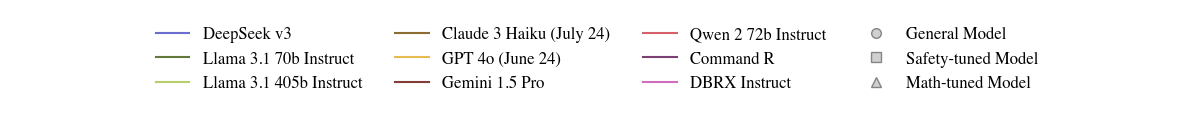

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

# ==============================================================================
# 1. DEFINE DATA AND STYLES (Copied from your original script)
# ==============================================================================

# Model classification, names, and the list of models to include
model_classification = {
    'deepseek-ai/deepseek-v3': 'math',
    'meta/llama-3.1-70b-instruct-turbo': 'math',
    'meta/llama-3.1-405b-instruct-turbo': 'math',
    'anthropic/claude-3-haiku-20240307': 'safety',
    'openai/gpt-4o-2024-08-06': 'general',
    'google/gemini-1.5-pro-002': 'general',
    'qwen/qwen2-72b-instruct': 'math',
    'cohere/command-r': 'safety',
    'databricks/dbrx-instruct': 'math'
}

models_to_name = {
    'deepseek-ai/deepseek-v3': 'DeepSeek v3',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70b Instruct',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405b Instruct',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku (July 24)',
    'openai/gpt-4o-2024-08-06': 'GPT 4o (June 24)',
    'google/gemini-1.5-pro-002': 'Gemini 1.5 Pro',
    'qwen/qwen2-72b-instruct': 'Qwen 2 72b Instruct',
    'cohere/command-r': 'Command R',
    'databricks/dbrx-instruct': 'DBRX Instruct'
}

models_to_highlight = list(model_classification.keys())

# Color map generation logic
def clipped_cmap(cmap, minval=0.08, maxval=0.92, n=256):
    """Creates a clipped version of a colormap."""
    return LinearSegmentedColormap.from_list(
        f'clipped({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )

highlight_cmap = clipped_cmap(plt.get_cmap('tab20b'), minval=0.1)
num_highlight = len(models_to_highlight)
highlight_colors = [highlight_cmap(i / max(num_highlight - 1, 1)) for i in range(num_highlight)]
highlight_color_map = dict(zip(models_to_highlight, highlight_colors))


# ==============================================================================
# 2. GENERATE LEGEND HANDLES
# ==============================================================================

# Create handles for the model names (colored lines)
model_handles = []
for model_id in models_to_highlight:
    display_name = models_to_name[model_id]
    color = highlight_color_map[model_id]
    # Create a Line2D object for each model to serve as its legend entry
    handle = Line2D([0], [0], color=color, lw=1.5, label=display_name)
    model_handles.append(handle)

# Create custom handles for the model types (shapes), exactly as in your script
shape_handles = [
    Line2D([0], [0], marker='o', markerfacecolor='#44444440', markeredgecolor='#44444499', label='General Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='s', markerfacecolor='#44444440', markeredgecolor='#44444499', label='Safety-tuned Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='^', markerfacecolor='#44444440', markeredgecolor='#44444499', label='Math-tuned Model',
           linestyle='None', markersize=7)
]

# Combine all handles into a single list
all_handles = model_handles + shape_handles


# ==============================================================================
# 3. CREATE AND SAVE THE LEGEND
# ==============================================================================

# Create a new figure specifically for the legend.
# The figsize is an estimate; `bbox_inches='tight'` will handle the final cropping.
fig_legend = plt.figure(figsize=(12, 1.25))

# Create the legend in the center of the figure.
# The parameters (ncol, fontsize, frameon) are identical to your original code.
leg = fig_legend.legend(
    handles=all_handles,
    loc='center',
    ncol=4,
    fontsize=12,
    frameon=False
)

# Turn off the axes, as we only want the legend itself
plt.axis('off')

# Save the figure to a PDF file.
# `bbox_inches='tight'` crops the saved file to the boundary of the legend.
# `pad_inches` adds a small amount of whitespace padding.
plt.savefig('../result/combined_math_safety_analysis_legend_only.pdf', bbox_inches='tight')

# Optionally, display the legend in a plot window
plt.show()

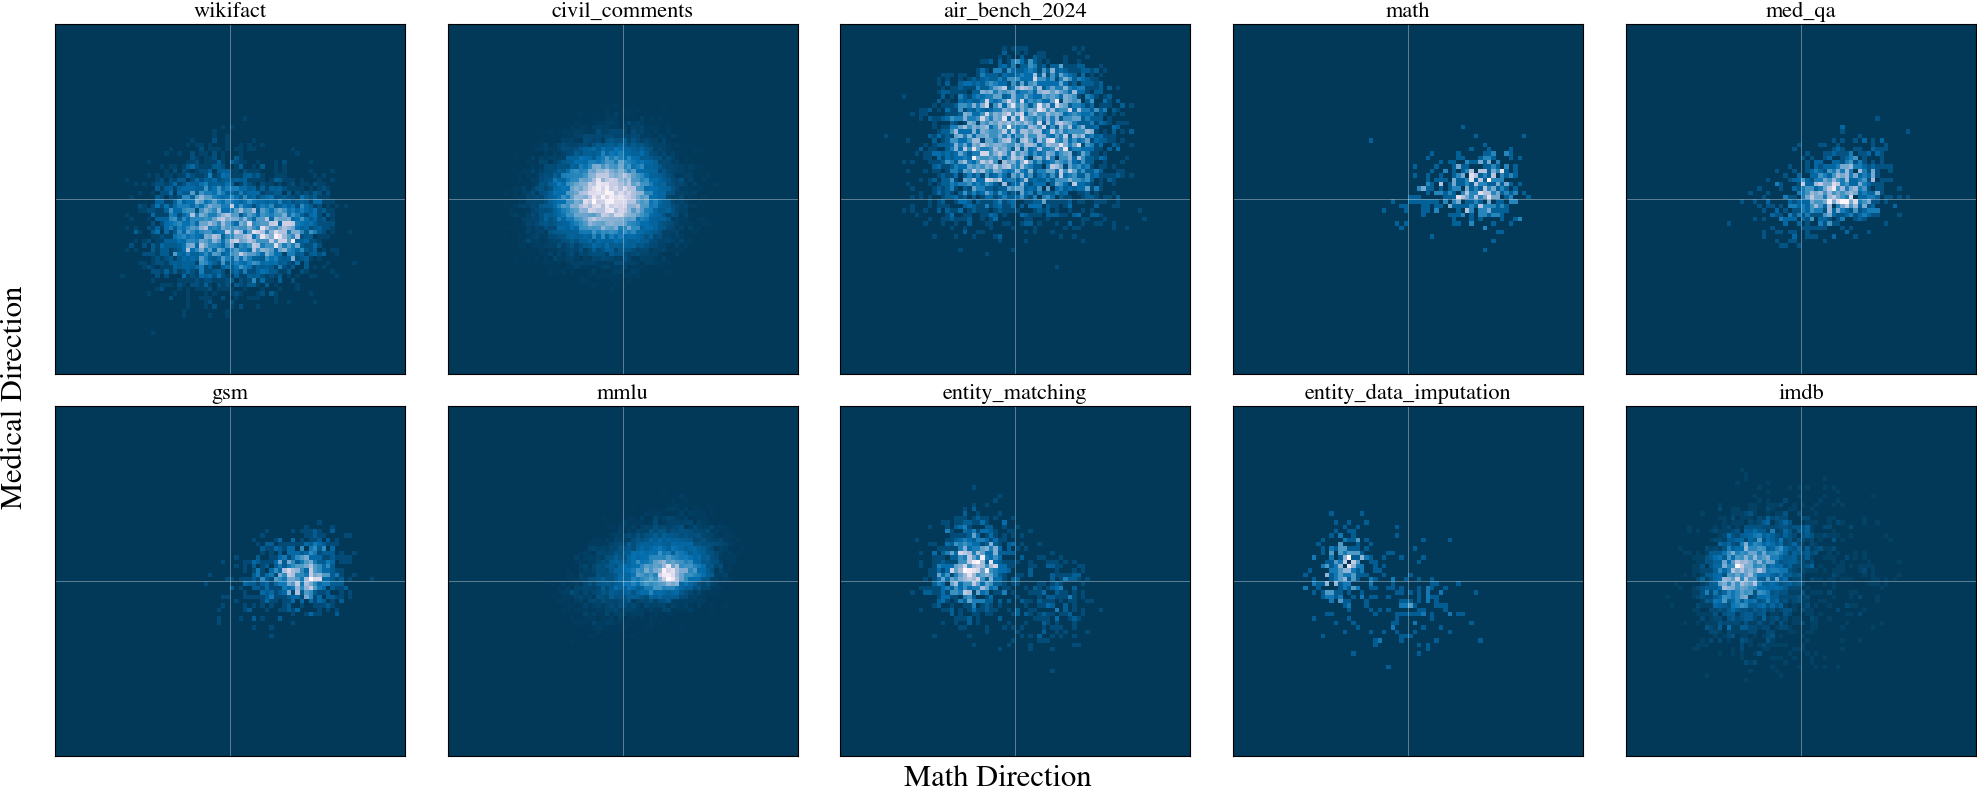

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'wikifact',
    'civil_comments', 'air_bench_2024', 'math',
    'med_qa', 'gsm', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = results_math['v']
v2 = results_safety['v']
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=16)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("Math Direction", fontsize=22)
fig.supylabel("Medical Direction", fontsize=22)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings.pdf')
plt.show()

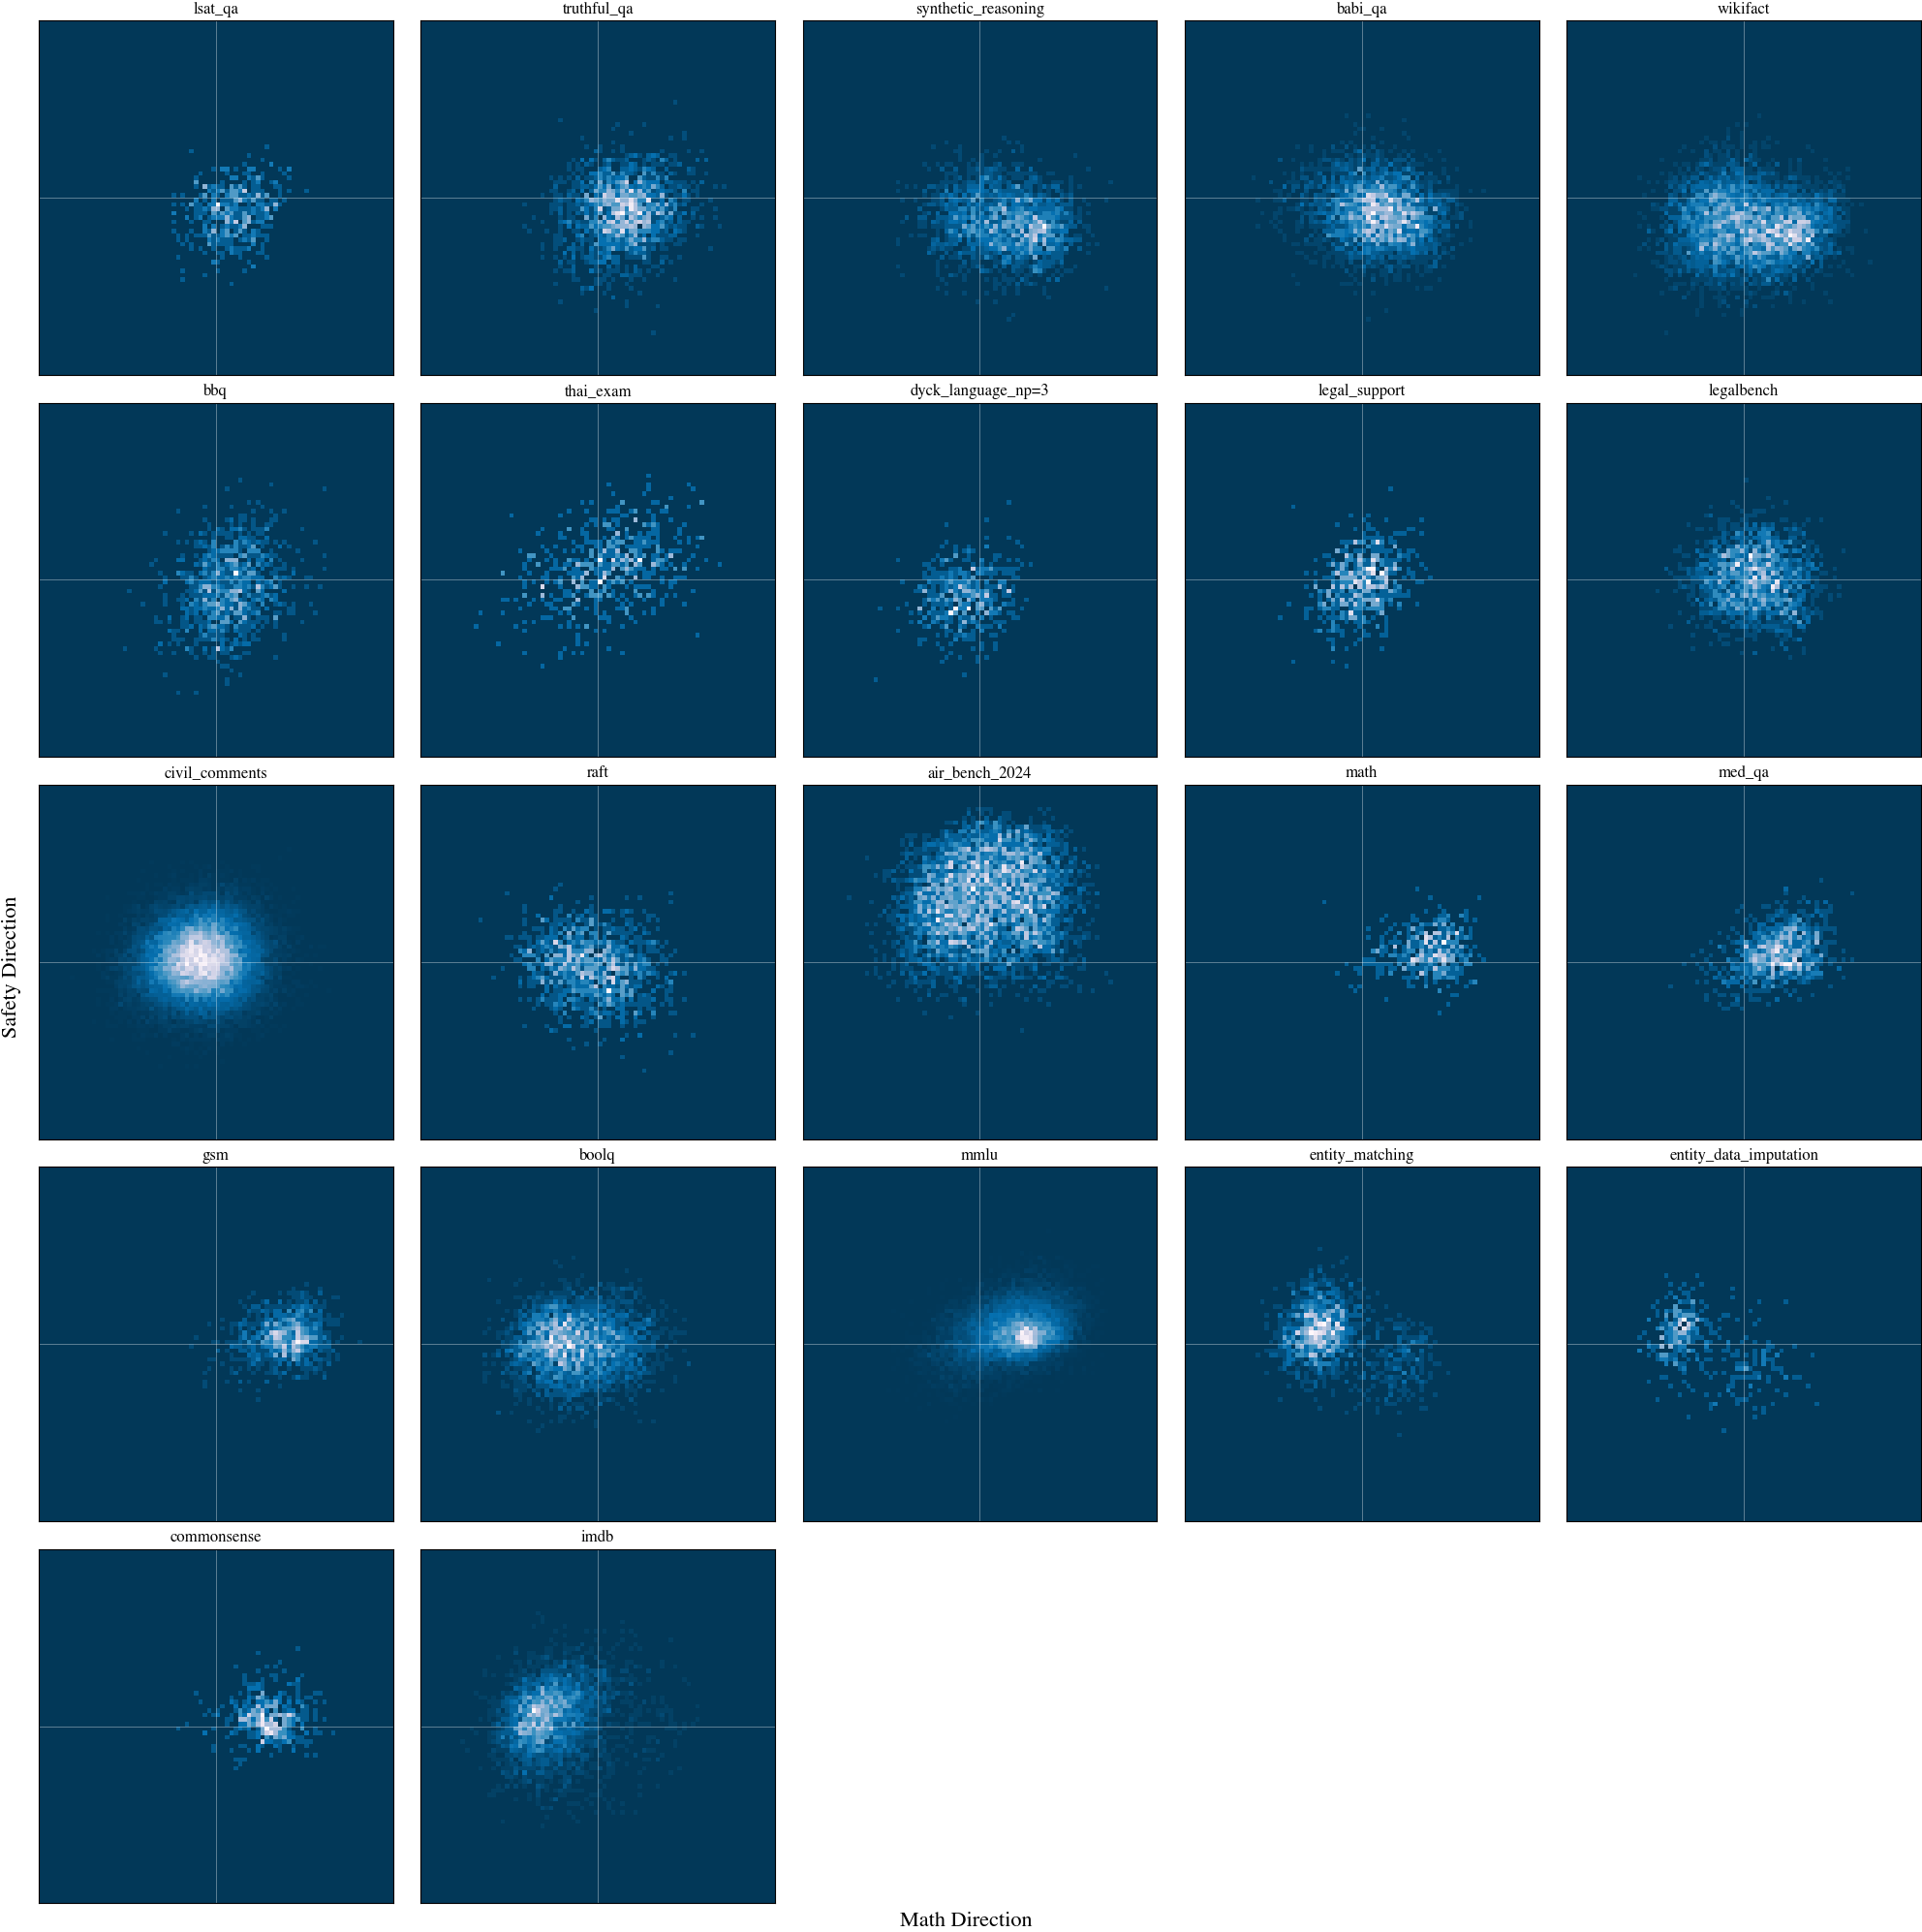

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
    'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support',
    'legalbench', 'civil_comments', 'raft', 'air_bench_2024', 'math',
    'med_qa', 'gsm', 'boolq', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'commonsense', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = results_math['v']
v2 = results_safety['v']
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("Math Direction", fontsize=16)
fig.supylabel("Safety Direction", fontsize=16)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings_full.pdf')
plt.show()

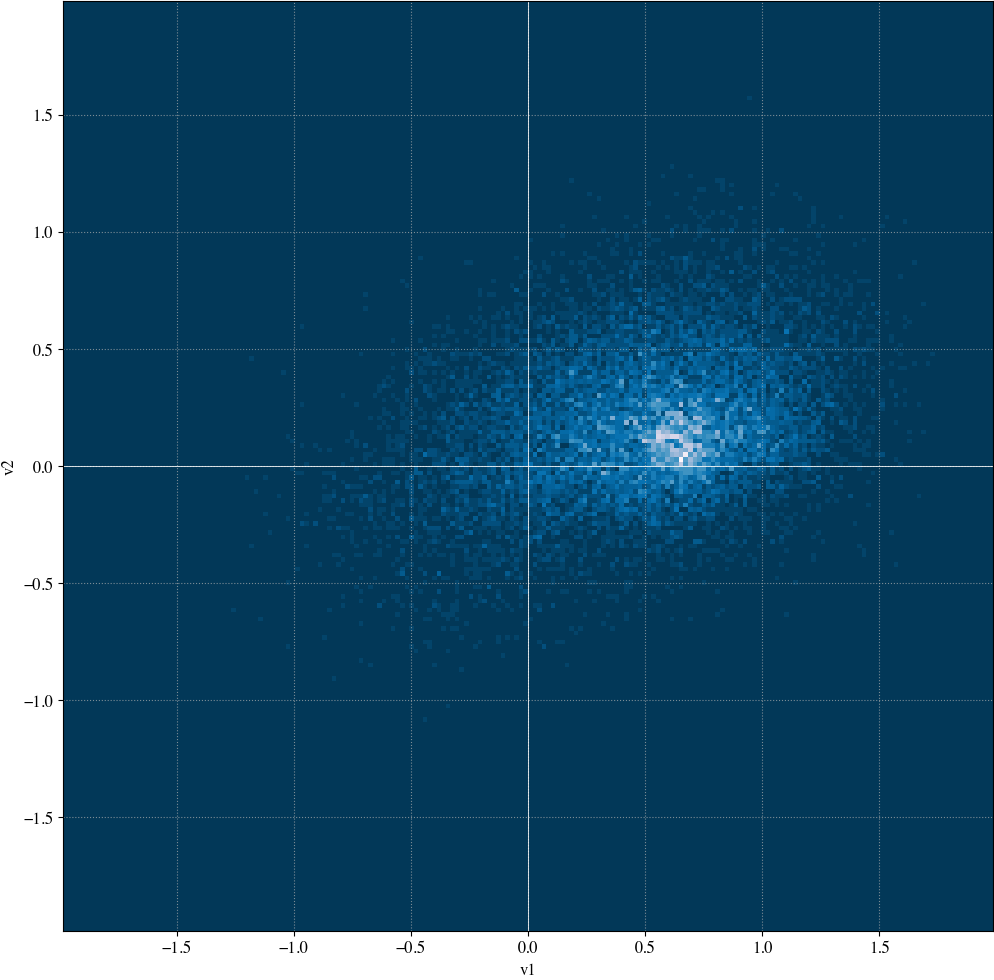

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

examine_dataset = ['mmlu']

models = resmat.index.to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(examine_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

med_qa_vectors = a_df.loc[scenario_questions].to_numpy()
v1 = results_math['v']
v2 = results_safety['v']


# --- 3. Project the MedQA vectors onto the new basis ---
# The new coordinates are simply the dot products with the normalized basis vectors.
# This section remains the same.

# coords_x will be the projection onto the v1 direction
coords_x = med_qa_vectors @ v1
# coords_y will be the projection onto the v2 direction
coords_y = med_qa_vectors @ v2


# --- 4. Create the Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.hist2d(coords_x, coords_y, bins=250, range=hist_range, cmap='PuBu_r')

ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='white', lw=0.5, alpha=0.5)
ax.axvline(0, color='white', lw=0.5, alpha=0.5)
ax.set_facecolor('black')

ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)

# --- 5. Format the Plot ---
# This section is mostly the same, with an updated title.
# Set axis limits to be symmetrical and slightly larger than the data
max_lim = max(np.abs(coords_x).max(), np.abs(coords_y).max()) * 1.15
ax.set_xlim([-max_lim, max_lim])
ax.set_ylim([-max_lim, max_lim])

# Add central axis lines
ax.axhline(0, color='white', lw=0.5)
ax.axvline(0, color='white', lw=0.5)

# Add labels and title
ax.set_xlabel("v1", fontsize=12)
ax.set_ylabel("v2", fontsize=12)

# Make the plot square and add a grid
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [11]:
import numpy as np

top_n = 50

# Use np.argsort to get the indices that would sort the arrays
sorted_indices_x = np.argsort(coords_x)
sorted_indices_y = np.argsort(coords_y)

# Get the indices for the top 10 in each of the four extremes
indices_max_x = sorted_indices_x[-top_n:][::-1] # Top 10 largest x (reversed to show #1 first)
indices_min_x = sorted_indices_x[:top_n]      # Top 10 smallest x
indices_max_y = sorted_indices_y[-top_n:][::-1] # Top 10 largest y (reversed)
indices_min_y = sorted_indices_y[:top_n]      # Top 10 smallest y

print("--- TOP 10 EXTREME POINTS ON THE PLOT ---")

# --- Print Top 10 Rightmost ---
print(f"\n➡️ Top {top_n} Most Positive on v1 (Rightmost, most Math-like):")
for i, idx in enumerate(indices_max_x):
    label = scenario_questions[idx]
    # Truncate long labels for cleaner printing
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")

# --- Print Top 10 Topmost ---
print(f"\n⬆️ Top {top_n} Most Positive on v2 (Topmost, most med_qa-like):")
for i, idx in enumerate(indices_max_y):
    label = scenario_questions[idx]
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")


--- TOP 10 EXTREME POINTS ON THE PLOT ---

➡️ Top 50 Most Positive on v1 (Rightmost, most Math-like):
    1. (1.7268, 0.4873) - This question refers to the following information. The condition of foreign...
    2. (1.7068, 0.4320) - Order the following (risk, return) pairs from least to most favourable, ass...
    3. (1.6965, 0.6936) - In which era did muckraking journalism led to the widespread introduction o...
    4. (1.6873, 0.1379) - Which of the following is not a 'research purpose'?
    5. (1.6730, -0.1357) - Aronson and Mills examined the effects severity of initiation into a group ...
    6. (1.6730, 0.2716) - Which of the following procedures would an accountant least likely perform ...
    7. (1.6535, 0.8679) - Which of the following is a characteristic of a developed country?
    8. (1.6477, 0.4448) - When using multiple regression, multicollinearity occurs when:
    9. (1.6295, 0.1424) - Find the LCM of 24 and 36.
   10. (1.6240, 0.1123) - Let F be a constant unit force th